# M66 Bus Stop-Level Ridership Dataset Cleaning and Analysis

**Project:** Passenger Queue Dynamics and Waiting-Time Simulation for Selected M66 Bus Stops

In [1]:
# DATASET SOURCE
# MTA Bus Stop Level Ridership: Beginning 2024
# Provider: Metropolitan Transportation Authority (MTA)
# Dataset ID: fvdm-uavx
# Current source dataset size before project filtering: 155,387,648 records
# Data last updated: July 25, 2026
# https://data.ny.gov/d/fvdm-uavx

# DEVELOPMENT AND DOCUMENTATION NOTE
# AI-assisted suggestions were used as a starting point for portions of the Python code.
# The member responsible for Dataset Analysis determined the filtering, cleaning,
# analysis, validation, and visualization logic; adapted and implemented the final code;
# verified outputs using the actual MTA datasets and official documentation; and
# interpreted the results.
# Official pandas, NumPy, Matplotlib, Python, MTA, and GTFS documentation was consulted
# when implementing and verifying the required functions and procedures.

In [2]:
# Import the libraries used for data preparation, analysis, and visualization.
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

## 1. Load and Verify the Raw Ridership Data

In [3]:
# Define the location of the untouched project extract.
raw_file = Path("../data/raw/MTA_M66_Eastbound_2025_RAW.csv")

# Reference: pandas.read_csv()
# https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html
# Load the raw CSV without modifying the source file.
df_raw = pd.read_csv(raw_file, low_memory=False)

# Verify the downloaded file size and expected variables.
print("Dataset shape:", df_raw.shape)
print("Columns:", df_raw.columns.tolist())

# Preview the first five records.
df_raw.head()

Dataset shape: (86959, 9)
Columns: ['Date', 'Hour', 'Route ID', 'Direction', 'Stop ID', 'Stop Sequence', 'Boardings', 'Alightings', 'Trips']


,Date,Hour,Route ID,Direction,Stop ID,Stop Sequence,Boardings,Alightings,Trips
0,2025-01-01,2025-01-01 05:00:00 AM,M66,E,403491,4,3,0,1
1,2025-01-01,2025-01-01 05:00:00 AM,M66,E,403492,6,1,0,1
2,2025-01-01,2025-01-01 05:00:00 AM,M66,E,403497,10,0,1,1
3,2025-01-01,2025-01-01 05:00:00 AM,M66,E,403994,12,0,1,1
4,2025-01-01,2025-01-01 05:00:00 AM,M66,E,403996,14,0,2,1


In [4]:
# Check how pandas interpreted the variables and confirm non-null counts.
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 86959 entries, 0 to 86958
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Date           86959 non-null  str  
 1   Hour           86959 non-null  str  
 2   Route ID       86959 non-null  str  
 3   Direction      86959 non-null  str  
 4   Stop ID        86959 non-null  int64
 5   Stop Sequence  86959 non-null  int64
 6   Boardings      86959 non-null  int64
 7   Alightings     86959 non-null  int64
 8   Trips          86959 non-null  int64
dtypes: int64(5), str(4)
memory usage: 6.0 MB


## 2. Convert and Filter the Ridership Data

In [5]:
# Create a working copy so the imported raw DataFrame remains unchanged.
df = df_raw.copy()

# Reference: pandas.to_datetime()
# https://pandas.pydata.org/docs/reference/api/pandas.to_datetime.html
# Convert Date to datetime so calendar-based filtering can be applied.
df["Date"] = pd.to_datetime(df["Date"])

# Convert Hour to datetime so the numeric study hour can be extracted.
df["Hour"] = pd.to_datetime(df["Hour"])

df[["Date", "Hour"]].head()

,Date,Hour
0,2025-01-01,2025-01-01 05:00:00
1,2025-01-01,2025-01-01 05:00:00
2,2025-01-01,2025-01-01 05:00:00
3,2025-01-01,2025-01-01 05:00:00
4,2025-01-01,2025-01-01 05:00:00


In [6]:
# Reference: pandas Series.dt.dayofweek
# https://pandas.pydata.org/docs/reference/api/pandas.Series.dt.dayofweek.html
# Keep Monday through Friday records; pandas uses 0-4 for Monday-Friday.
df_weekday = df[df["Date"].dt.dayofweek < 5].copy()

print("Before weekday filter:", len(df))
print("After weekday filter:", len(df_weekday))

Before weekday filter: 86959
After weekday filter: 64531


In [7]:
# Define the morning and evening starting hours included in the simulation.
study_hours = [6, 7, 8, 9, 10, 15, 16, 17, 18, 19]

# Reference: pandas Series.dt.hour
# https://pandas.pydata.org/docs/reference/api/pandas.Series.dt.hour.html
# Keep only records whose hour belongs to the study-hour list.
df_hours = df_weekday[
    df_weekday["Hour"].dt.hour.isin(study_hours)
].copy()

print("Before study-hour filter:", len(df_weekday))
print("After study-hour filter:", len(df_hours))

Before study-hour filter: 64531
After study-hour filter: 35372


In [8]:
# Define stop sequences 6 through 10 as the modeled M66 stops.
selected_sequences = [6, 7, 8, 9, 10]

# Keep only records belonging to the five selected stop sequences.
df_selected = df_hours[
    df_hours["Stop Sequence"].isin(selected_sequences)
].copy()

# Upstream stops are not selected here by Stop Sequence alone because the raw
# M66 file contains more than one service pattern. The verified physical
# upstream Stop IDs are identified later from the full-route GTFS pattern.

print("Study-hour records:", len(df_hours))
print("Selected stop records:", len(df_selected))

Study-hour records: 35372
Selected stop records: 12815


## 3. Data Quality Checks

In [9]:
# Count missing cell values in the selected-stop dataset.
missing_cell_values = int(df_selected.isna().sum().sum())

# Count exact duplicate rows.
exact_duplicates = int(df_selected.duplicated().sum())

# Check whether the same Date + Hour + Stop Sequence appears more than once.
logical_duplicates = int(
    df_selected.duplicated(
        subset=["Date", "Hour", "Stop Sequence"]
    ).sum()
)

print("Missing cell values:", missing_cell_values)
print("Exact duplicate rows:", exact_duplicates)
print("Logical duplicate rows:", logical_duplicates)

Missing cell values: 0
Exact duplicate rows: 0
Logical duplicate rows: 0


In [10]:
# Count impossible negative values across the three count variables.
negative_values = int(
    (df_selected["Boardings"] < 0).sum()
    + (df_selected["Alightings"] < 0).sum()
    + (df_selected["Trips"] < 0).sum()
)

print("Negative values found:", negative_values)

Negative values found: 0


In [11]:
# Identify rows where Trips is zero but passenger activity is still recorded.
zero_trip_issue = df_selected[
    (df_selected["Trips"] == 0)
    & (
        (df_selected["Boardings"] > 0)
        | (df_selected["Alightings"] > 0)
    )
].copy()

print("Rows with passenger activity but zero trips:", len(zero_trip_issue))

zero_trip_issue

Rows with passenger activity but zero trips: 1


,Date,Hour,Route ID,Direction,Stop ID,Stop Sequence,Boardings,Alightings,Trips
31500,2025-05-13,2025-05-13 18:00:00,M66,E,403494,7,0,2,0


In [12]:
# Remove only the internally inconsistent zero-trip/passenger-activity record.
df_clean = df_selected[
    ~(
        (df_selected["Trips"] == 0)
        & (
            (df_selected["Boardings"] > 0)
            | (df_selected["Alightings"] > 0)
        )
    )
].copy()

print("Before removal:", len(df_selected))
print("After removal:", len(df_clean))

Before removal: 12815
After removal: 12814


In [13]:
# Reference: pandas.date_range()
# https://pandas.pydata.org/docs/reference/api/pandas.date_range.html
# Generate every Monday-Friday date in 2025.
weekdays = pd.date_range(
    "2025-01-01",
    "2025-12-31",
    freq="B"
)

# Build every expected Date x Hour x Stop Sequence combination.
expected = pd.MultiIndex.from_product(
    [weekdays, study_hours, selected_sequences],
    names=["Date", "Hour", "Stop Sequence"]
).to_frame(index=False)

# Use the original selected records to measure combinations that were absent from the source data.
actual_preclean = df_selected[
    ["Date", "Hour", "Stop Sequence"]
].copy()

# Convert Hour to a numeric value so it matches the expected grid.
actual_preclean["Hour"] = actual_preclean["Hour"].dt.hour

# Compare expected combinations with combinations present before cleaning.
missing_source = expected.merge(
    actual_preclean.drop_duplicates(),
    on=["Date", "Hour", "Stop Sequence"],
    how="left",
    indicator=True
)

# Keep only expected combinations that were absent from the source records.
missing_source = missing_source[
    missing_source["_merge"] == "left_only"
].drop(columns="_merge")

# Use the final cleaned records to measure all combinations unavailable after cleaning.
actual_clean = df_clean[
    ["Date", "Hour", "Stop Sequence"]
].copy()

# Convert Hour to a numeric value so it matches the expected grid.
actual_clean["Hour"] = actual_clean["Hour"].dt.hour

# Compare expected combinations with the final cleaned combinations.
unavailable_clean = expected.merge(
    actual_clean.drop_duplicates(),
    on=["Date", "Hour", "Stop Sequence"],
    how="left",
    indicator=True
)

# Keep combinations unavailable in the final cleaned dataset.
unavailable_clean = unavailable_clean[
    unavailable_clean["_merge"] == "left_only"
].drop(columns="_merge")

print("Expected combinations:", len(expected))
print("Absent from source data:", len(missing_source))
print("Unavailable after cleaning:", len(unavailable_clean))

Expected combinations: 13050
Absent from source data: 235
Unavailable after cleaning: 236


In [14]:
# Count source-absent combinations by stop sequence.
missing_by_stop = (
    missing_source["Stop Sequence"]
    .value_counts()
    .sort_index()
)

# Count source-absent combinations by study hour.
missing_by_hour = (
    missing_source["Hour"]
    .value_counts()
    .sort_index()
)

print("Source-absent combinations by stop:")
print(missing_by_stop)

print("\nSource-absent combinations by hour:")
print(missing_by_hour)

Source-absent combinations by stop:
Stop Sequence
6     35
7     79
8     59
9     50
10    12
Name: count, dtype: int64

Source-absent combinations by hour:
Hour
6     43
7     15
8     18
9     17
10    21
15    10
16    14
17     7
18    13
19    77
Name: count, dtype: int64


## 4. GTFS Verification and Stop Mapping

In [15]:
# MTA static GTFS source:
# https://www.mta.info/developers
# GTFS Schedule Reference:
# https://gtfs.org/documentation/schedule/reference/

# Load feed_info.txt to record the exact GTFS feed version used by the project.
feed_info = pd.read_csv("../data/raw/gtfs_m/feed_info.txt")

# Display the publisher, feed coverage dates, and version for reproducibility.
feed_info[
    [
        "feed_publisher_name",
        "feed_start_date",
        "feed_end_date",
        "feed_version"
    ]
]

,feed_publisher_name,feed_start_date,feed_end_date,feed_version
0,MTA New York City Transit,20260627,20260905,gtfs_m_20260611T155328Z


In [16]:
# Load GTFS trip records.
trips = pd.read_csv("../data/raw/gtfs_m/trips.txt")

# Keep eastbound M66 trips so the available service and shape patterns can be inspected.
m66_eastbound = trips[
    (trips["route_id"] == "M66")
    & (trips["direction_id"] == 0)
]

# Show distinct weekday/weekend service and shape combinations before selecting the final pattern.
m66_eastbound[
    ["service_id", "trip_headsign", "shape_id"]
].drop_duplicates()

,service_id,trip_headsign,shape_id
0,MQ_C6-Weekday,EAST SIDE YORK AV CROSSTOWN,M660030
193,MQ_C6-Weekday,EAST SIDE YORK AV CROSSTOWN,M660028
4007,MQ_C6-Saturday,EAST SIDE YORK AV CROSSTOWN,M660030
7334,MQ_C6-Sunday,EAST SIDE YORK AV CROSSTOWN,M660030
21719,MQ_C6-Weekday-SDon,EAST SIDE YORK AV CROSSTOWN,M660030
21912,MQ_C6-Weekday-SDon,EAST SIDE YORK AV CROSSTOWN,M660028


In [17]:
# Load recurring GTFS service calendars.
calendar = pd.read_csv("../data/raw/gtfs_m/calendar.txt")

# Load date-specific GTFS service additions and removals.
calendar_dates = pd.read_csv("../data/raw/gtfs_m/calendar_dates.txt")

# Inspect the two weekday service IDs found in the current M66 feed.
weekday_calendar = calendar[
    calendar["service_id"].isin([
        "MQ_C6-Weekday",
        "MQ_C6-Weekday-SDon"
    ])
]

# Summarize how the two weekday service IDs are added or removed on specific dates.
weekday_exceptions = (
    calendar_dates[
        calendar_dates["service_id"].isin([
            "MQ_C6-Weekday",
            "MQ_C6-Weekday-SDon"
        ])
    ]
    .groupby(["service_id", "exception_type"])
    .size()
)

print("Recurring weekday calendar:")
display(weekday_calendar)

print("Service exception counts:")
display(weekday_exceptions)

Recurring weekday calendar:


,service_id,monday,tuesday,wednesday,thursday,friday,saturday,sunday,start_date,end_date
1,MQ_C6-Weekday-SDon,1,1,1,1,1,0,0,20260629,20260904


Service exception counts:


service_id          exception_type
MQ_C6-Weekday       1                 14
MQ_C6-Weekday-SDon  2                 15
dtype: int64

In [18]:
# List dates when MQ_C6-Weekday is specifically added.
weekday_added = calendar_dates[
    (calendar_dates["service_id"] == "MQ_C6-Weekday")
    & (calendar_dates["exception_type"] == 1)
]["date"].tolist()

# List dates when MQ_C6-Weekday-SDon is specifically removed.
sdon_removed = calendar_dates[
    (calendar_dates["service_id"] == "MQ_C6-Weekday-SDon")
    & (calendar_dates["exception_type"] == 2)
]["date"].tolist()

print("MQ_C6-Weekday added:")
print(weekday_added)

print("\nMQ_C6-Weekday-SDon removed:")
print(sdon_removed)

MQ_C6-Weekday added:
[20260629, 20260630, 20260820, 20260821, 20260824, 20260825, 20260826, 20260827, 20260828, 20260831, 20260901, 20260902, 20260903, 20260904]

MQ_C6-Weekday-SDon removed:
[20260703, 20260629, 20260630, 20260820, 20260821, 20260824, 20260825, 20260826, 20260827, 20260828, 20260831, 20260901, 20260902, 20260903, 20260904]


In [19]:
# Select the current weekday eastbound M66 service used by the project.
m66_current = trips[
    (trips["route_id"] == "M66")
    & (trips["direction_id"] == 0)
    & (trips["service_id"] == "MQ_C6-Weekday")
    & (
        trips["trip_headsign"]
        == "EAST SIDE YORK AV CROSSTOWN"
    )
].copy()

# Count the available route shapes before choosing the full route pattern.
m66_current["shape_id"].value_counts()

shape_id
M660030    138
M660028      3
Name: count, dtype: int64

In [20]:
# Select the full eastbound M66 route shape that contains the modeled segment.
m66_full = m66_current[
    m66_current["shape_id"] == "M660030"
].copy()

# Load GTFS stop times and stop metadata.
stop_times = pd.read_csv("../data/raw/gtfs_m/stop_times.txt")
stops = pd.read_csv("../data/raw/gtfs_m/stops.txt")

# Keep trip IDs and shape IDs needed to link selected trips to their ordered stops.
shape_trips = m66_current[
    ["trip_id", "shape_id"]
]

# Join stop times to the selected M66 trips and readable stop names.
shape_stops = (
    stop_times
    .merge(shape_trips, on="trip_id")
    .merge(stops[["stop_id", "stop_name"]], on="stop_id")
)

# Create one ordered stop record per shape/sequence combination.
shape_stops_unique = (
    shape_stops[
        ["shape_id", "stop_sequence", "stop_id", "stop_name"]
    ]
    .drop_duplicates()
    .sort_values(["shape_id", "stop_sequence"])
)

# Summarize the two current eastbound shapes to verify that M660030 is the full pattern.
shape_summary = shape_stops_unique.groupby("shape_id").agg(
    Stops=("stop_sequence", "count"),
    First_Stop=("stop_name", "first"),
    Last_Stop=("stop_name", "last")
)

shape_summary

,Stops,First_Stop,Last_Stop
shape_id,,,
M660028,5,E 68 ST/LEXINGTON AV,E 68 ST/YORK AV
M660030,14,W 66 ST/WEST END AV,E 68 ST/YORK AV


In [21]:
# Keep the five modeled stops from the verified full-route shape.
gtfs_selected_stops = shape_stops_unique[
    (shape_stops_unique["shape_id"] == "M660030")
    & (shape_stops_unique["stop_sequence"].between(6, 10))
][
    ["stop_sequence", "stop_id", "stop_name"]
].copy()

# Save the verified GTFS stop mapping as reproducibility evidence.
gtfs_selected_stops.to_csv(
    "../outputs/tables/gtfs_selected_stop_mapping.csv",
    index=False
)

gtfs_selected_stops

,stop_sequence,stop_id,stop_name
5,6,403492,W 65 ST/CENTRAL PARK WEST
6,7,403494,E 65 ST/5 AV
7,8,400027,MADISON AV/E 65 ST
8,9,405489,MADISON AV/E 67 ST
9,10,405627,E 68 ST/LEXINGTON AV


In [22]:
# Keep the five physical upstream stops from the same verified full-route shape.
# This avoids mixing the short M66 pattern into the upstream occupancy input.
gtfs_upstream_stops = shape_stops_unique[
    (shape_stops_unique["shape_id"] == "M660030")
    & (shape_stops_unique["stop_sequence"].between(1, 5))
][
    ["stop_sequence", "stop_id", "stop_name"]
].copy()

# Save the verified upstream mapping for the simulation notebook.
gtfs_upstream_stops.to_csv(
    "../outputs/tables/gtfs_upstream_stop_mapping.csv",
    index=False
)

gtfs_upstream_stops

,stop_sequence,stop_id,stop_name
0,1,403487,W 66 ST/WEST END AV
1,2,403488,W 65 ST/WEST END AV
2,3,403489,W 65 ST/AMSTERDAM AV
3,4,403491,W 65 ST/BROADWAY
4,5,403573,W 65 ST/COLUMBUS AV


In [23]:
# Link stop times only to trips using the verified full-route shape.
trip_times = stop_times.merge(
    m66_full[["trip_id"]],
    on="trip_id"
)

# Use stop sequence 6 as the first selected-stop event for assigning trips to study hours.
trip_times = trip_times[
    trip_times["stop_sequence"] == 6
].copy()

# Extract the scheduled arrival hour from the GTFS HH:MM:SS value.
trip_times["hour"] = (
    trip_times["arrival_time"]
    .str.split(":")
    .str[0]
    .astype(int)
)

# Count unique full-route trips whose first selected-stop arrival occurs in the morning study hours.
morning_trips = trip_times[
    trip_times["hour"].isin([6, 7, 8, 9, 10])
]["trip_id"].nunique()

# Count unique full-route trips whose first selected-stop arrival occurs in the evening study hours.
evening_trips = trip_times[
    trip_times["hour"].isin([15, 16, 17, 18, 19])
]["trip_id"].nunique()

print("Morning trips:", morning_trips)
print("Evening trips:", evening_trips)
print("Total study-period trips:", morning_trips + evening_trips)

Morning trips: 43
Evening trips: 44
Total study-period trips: 87


In [24]:
# List historical ridership Stop IDs used for each selected stop sequence.
ridership_stop_ids = df_clean.groupby(
    "Stop Sequence"
)["Stop ID"].unique()

ridership_stop_ids

Stop Sequence
6             [403492]
7             [403494]
8             [404994]
9             [403495]
10    [403497, 405627]
Name: Stop ID, dtype: object

In [25]:
# Summarize when each historical Stop ID appears so identifier changes can be documented.
stop_id_dates = df_clean.groupby(
    ["Stop Sequence", "Stop ID"]
).agg(
    First_Date=("Date", "min"),
    Last_Date=("Date", "max"),
    Records=("Date", "count")
)

# Save the historical Stop ID history as cross-source mapping evidence.
stop_id_dates.reset_index().to_csv(
    "../outputs/tables/ridership_stop_id_history.csv",
    index=False
)

stop_id_dates

First_Date  Last_Date  Records
Stop Sequence Stop ID                               
6             403492  2025-01-01 2025-12-31     2575
7             403494  2025-01-01 2025-12-31     2530
8             404994  2025-01-01 2025-12-31     2551
9             403495  2025-01-01 2025-12-31     2560
10            403497  2025-01-01 2025-03-28      625
              405627  2025-03-31 2025-12-31     1973

In [26]:
# Build the stop-sequence-to-name mapping directly from the verified GTFS selected stops.
stop_names = dict(
    zip(
        gtfs_selected_stops["stop_sequence"],
        gtfs_selected_stops["stop_name"]
    )
)

# Add the verified current GTFS stop name to each historical ridership record by stop sequence.
df_clean["Stop Name"] = (
    df_clean["Stop Sequence"]
    .map(stop_names)
)

df_clean[
    ["Stop Sequence", "Stop Name"]
].drop_duplicates().sort_values("Stop Sequence")

,Stop Sequence,Stop Name
33,6,W 65 ST/CENTRAL PARK WEST
46,7,E 65 ST/5 AV
34,8,MADISON AV/E 65 ST
35,9,MADISON AV/E 67 ST
5,10,E 68 ST/LEXINGTON AV


In [27]:
# Assign each retained record to the morning or evening study period.
df_clean["Period"] = np.where(
    df_clean["Hour"].dt.hour < 12,
    "Morning",
    "Evening"
)

# Save the final cleaned selected-stop dataset once all derived fields are complete.
df_clean.to_csv(
    "../data/processed/MTA_M66_Selected_Stops_2025_CLEAN.csv",
    index=False
)

print("Final cleaned dataset saved.")
print("Dataset shape:", df_clean.shape)

Final cleaned dataset saved.
Dataset shape: (12814, 11)


## 5. Dataset Analysis

In [28]:
# Reference: pandas DataFrame.groupby()
# https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.groupby.html
# Summarize passenger activity by selected stop and study period.
stop_period_summary = df_clean.groupby(
    ["Stop Sequence", "Stop Name", "Period"]
).agg(
    Records=("Boardings", "count"),
    Avg_Boardings=("Boardings", "mean"),
    Avg_Alightings=("Alightings", "mean"),
    Avg_Trips=("Trips", "mean")
).round(2)

stop_period_summary

Records  Avg_Boardings  \
Stop Sequence Stop Name                 Period                            
6             W 65 ST/CENTRAL PARK WEST Evening     1289          25.36   
                                        Morning     1286          23.36   
7             E 65 ST/5 AV              Evening     1256           4.20   
                                        Morning     1274           4.36   
8             MADISON AV/E 65 ST        Evening     1278           3.79   
                                        Morning     1273           2.54   
9             MADISON AV/E 67 ST        Evening     1278           4.78   
                                        Morning     1282           5.65   
10            E 68 ST/LEXINGTON AV      Evening     1302          17.22   
                                        Morning     1296          63.90   

                                                 Avg_Alightings  Avg_Trips  
Stop Sequence Stop Name                 Period                              
6             W 65 ST/CENTRAL PARK WEST Evening            2.38       5.26  
                                        Morning            2.14       4.99  
7             E 65 ST/5 AV              Evening           11.21       4.35  
                                        Morning           20.98       4.90  
8             MADISON AV/E 65 ST        Evening           13.57       4.66  
                                        Morning           15.04       4.71  
9             MADISON AV/E 67 ST        Evening           12.99       4.78  
                                        Morning           12.75       4.73  
10            E 68 ST/LEXINGTON AV      Evening           41.72       6.09  
                                        Morning           27.79       5.73

In [29]:
# Calculate average boardings for each retained study hour.
hour_summary = df_clean.groupby(
    df_clean["Hour"].dt.hour
)["Boardings"].mean().round(2)

hour_summary

Hour
6     12.91
7     26.94
8     32.24
9     17.93
10    10.32
15    14.95
16    12.55
17    12.61
18     9.73
19     5.58
Name: Boardings, dtype: float64

In [30]:
# Compare overall average passenger activity and service between morning and evening.
period_summary = df_clean.groupby("Period").agg(
    Avg_Boardings=("Boardings", "mean"),
    Avg_Alightings=("Alightings", "mean"),
    Avg_Trips=("Trips", "mean")
).round(2)

period_summary

,Avg_Boardings,Avg_Alightings,Avg_Trips
Period,,,
Evening,11.14,16.46,5.03
Morning,20.11,15.75,5.01


In [31]:
# Calculate overall descriptive statistics for the boarding-count distribution.
boarding_stats = df_clean["Boardings"].describe().round(2)

# Calculate boarding statistics separately for each selected stop.
stop_stats = df_clean.groupby(
    ["Stop Sequence", "Stop Name"]
)["Boardings"].agg(
    Mean="mean",
    Median="median",
    Std="std",
    Min="min",
    Max="max"
).round(2)

print("Overall boarding statistics:")
display(boarding_stats)

print("Boarding statistics by stop:")
display(stop_stats)

Overall boarding statistics:


count    12814.00
mean        15.63
std         23.24
min          0.00
25%          3.00
50%          6.00
75%         19.00
max        206.00
Name: Boardings, dtype: float64

Boarding statistics by stop:


,,Mean,Median,Std,Min,Max
Stop Sequence,Stop Name,,,,,
6,W 65 ST/CENTRAL PARK WEST,24.36,22.0,14.74,0,94
7,E 65 ST/5 AV,4.28,3.0,4.07,0,48
8,MADISON AV/E 65 ST,3.17,3.0,2.85,0,35
9,MADISON AV/E 67 ST,5.22,5.0,4.21,0,76
10,E 68 ST/LEXINGTON AV,40.51,25.5,36.45,0,206


## 6. Visualizations

In [32]:
plt.style.use("default")

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "black",
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "text.color": "black",
    "grid.color": "#B0B0B0"
})

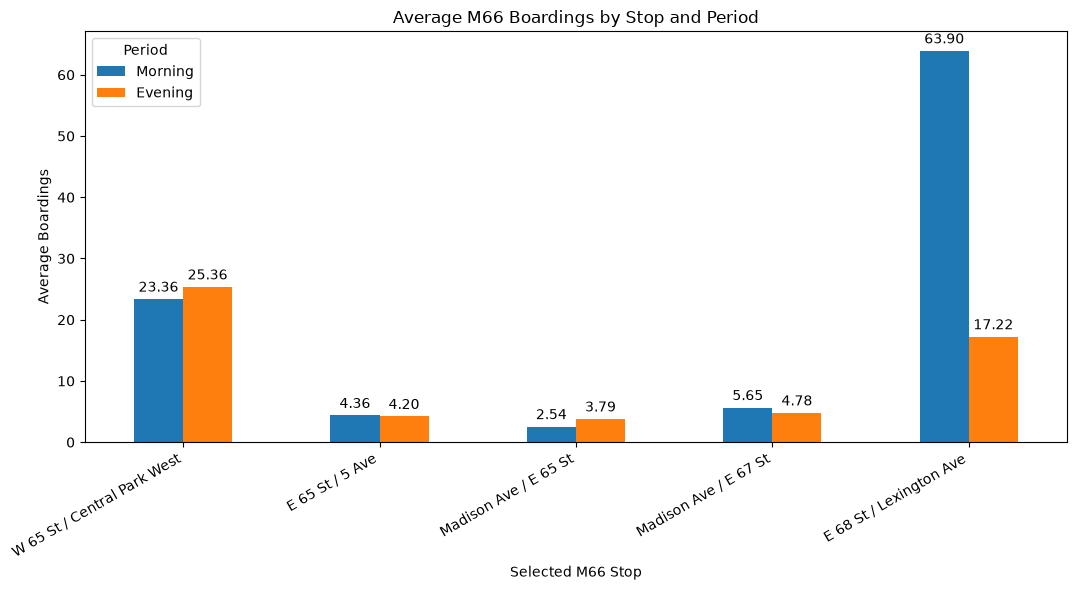

In [33]:
# Reference: Matplotlib bar charts
# https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.bar.html

# Preserve the physical eastbound route order in the chart.
stop_order = gtfs_selected_stops["stop_name"].tolist()

# Use shorter display labels while keeping the verified GTFS names in the dataset.
stop_labels = [
    "W 65 St / Central Park West",
    "E 65 St / 5 Ave",
    "Madison Ave / E 65 St",
    "Madison Ave / E 67 St",
    "E 68 St / Lexington Ave"
]

# Calculate average boardings by stop and period and reshape the periods into chart series.
chart1 = df_clean.groupby(
    ["Stop Name", "Period"]
)["Boardings"].mean().unstack()

# Reorder stops by route position and display Morning before Evening.
chart1 = chart1.loc[
    stop_order,
    ["Morning", "Evening"]
]

# Draw the grouped bar chart.
ax = chart1.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("Average M66 Boardings by Stop and Period")
plt.xlabel("Selected M66 Stop")
plt.ylabel("Average Boardings")

# Replace long GTFS names with shorter paper-friendly labels.
plt.xticks(
    range(len(stop_labels)),
    stop_labels,
    rotation=30,
    ha="right"
)

plt.legend(title="Period")

# Add the exact mean value above each bar.
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3)

plt.tight_layout()

# Save a 300-DPI copy for the paper.
plt.savefig(
    "../outputs/figures/01_average_boardings_by_stop_and_period.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

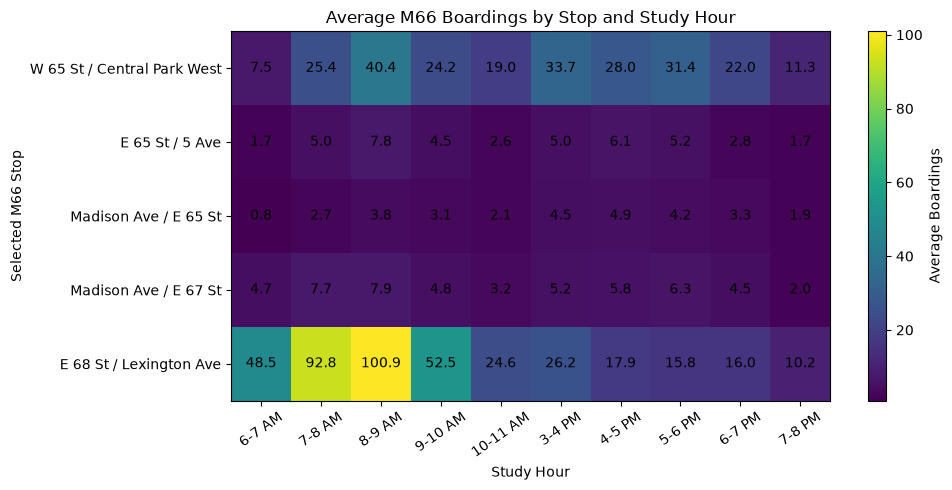

In [34]:
# Reference: Matplotlib imshow()
# https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.imshow.html

# Calculate average boardings for every selected stop-hour combination.
heatmap_data = df_clean.groupby(
    ["Stop Sequence", df_clean["Hour"].dt.hour]
)["Boardings"].mean().unstack()

# Reorder heatmap columns to follow the defined morning and evening study hours.
heatmap_data = heatmap_data[study_hours]

plt.figure(figsize=(10, 5))

# Draw the stop-by-hour boarding matrix as a heatmap.
plt.imshow(
    heatmap_data,
    aspect="auto"
)

plt.colorbar(label="Average Boardings")

# Label the heatmap columns with readable hourly intervals.
plt.xticks(
    range(len(study_hours)),
    [
        "6-7 AM", "7-8 AM", "8-9 AM", "9-10 AM", "10-11 AM",
        "3-4 PM", "4-5 PM", "5-6 PM", "6-7 PM", "7-8 PM"
    ],
    rotation=35
)

# Label the heatmap rows with the selected stop names.
plt.yticks(
    range(len(selected_sequences)),
    stop_labels
)

plt.title("Average M66 Boardings by Stop and Study Hour")
plt.xlabel("Study Hour")
plt.ylabel("Selected M66 Stop")

# Add each numeric mean inside its heatmap cell.
for i in range(len(selected_sequences)):
    for j in range(len(study_hours)):
        value = heatmap_data.iloc[i, j]
        plt.text(
            j,
            i,
            f"{value:.1f}",
            ha="center",
            va="center"
        )

plt.tight_layout()

# Save a 300-DPI copy for the paper.
plt.savefig(
    "../outputs/figures/02_average_boardings_by_stop_and_hour.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

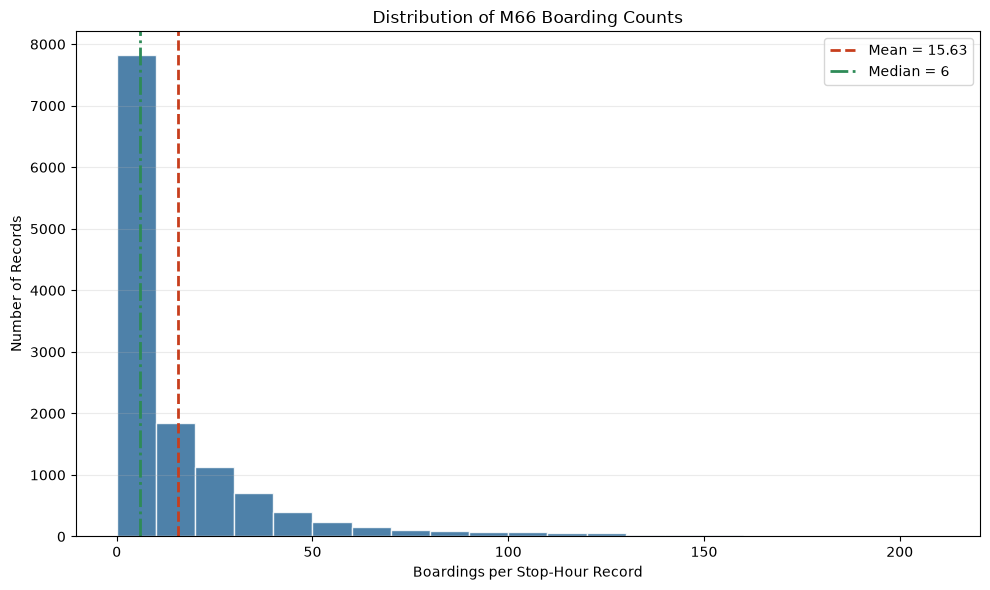

Mean boardings: 15.63
Median boardings: 6.0
Maximum boardings: 206


In [35]:
# Visualize the distribution of boarding counts across all retained records.
boarding_mean = df_clean["Boardings"].mean()
boarding_median = df_clean["Boardings"].median()
boarding_max = df_clean["Boardings"].max()

# Use 10-passenger intervals to make the right-skewed distribution readable.
histogram_bins = np.arange(
    0,
    boarding_max + 10,
    10
)

plt.figure(figsize=(10, 6))

plt.hist(
    df_clean["Boardings"],
    bins=histogram_bins,
    color="#2F6B9A",
    edgecolor="white",
    alpha=0.85
)

# Show the mean and median as reference lines.
plt.axvline(
    boarding_mean,
    color="#C73E1D",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {boarding_mean:.2f}"
)

plt.axvline(
    boarding_median,
    color="#2E8B57",
    linestyle="-.",
    linewidth=2,
    label=f"Median = {boarding_median:.0f}"
)

plt.title("Distribution of M66 Boarding Counts")
plt.xlabel("Boardings per Stop-Hour Record")
plt.ylabel("Number of Records")
plt.legend()
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()

plt.savefig(
    "../outputs/figures/05_boarding_count_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Mean boardings:", round(boarding_mean, 2))
print("Median boardings:", round(boarding_median, 2))
print("Maximum boardings:", boarding_max)

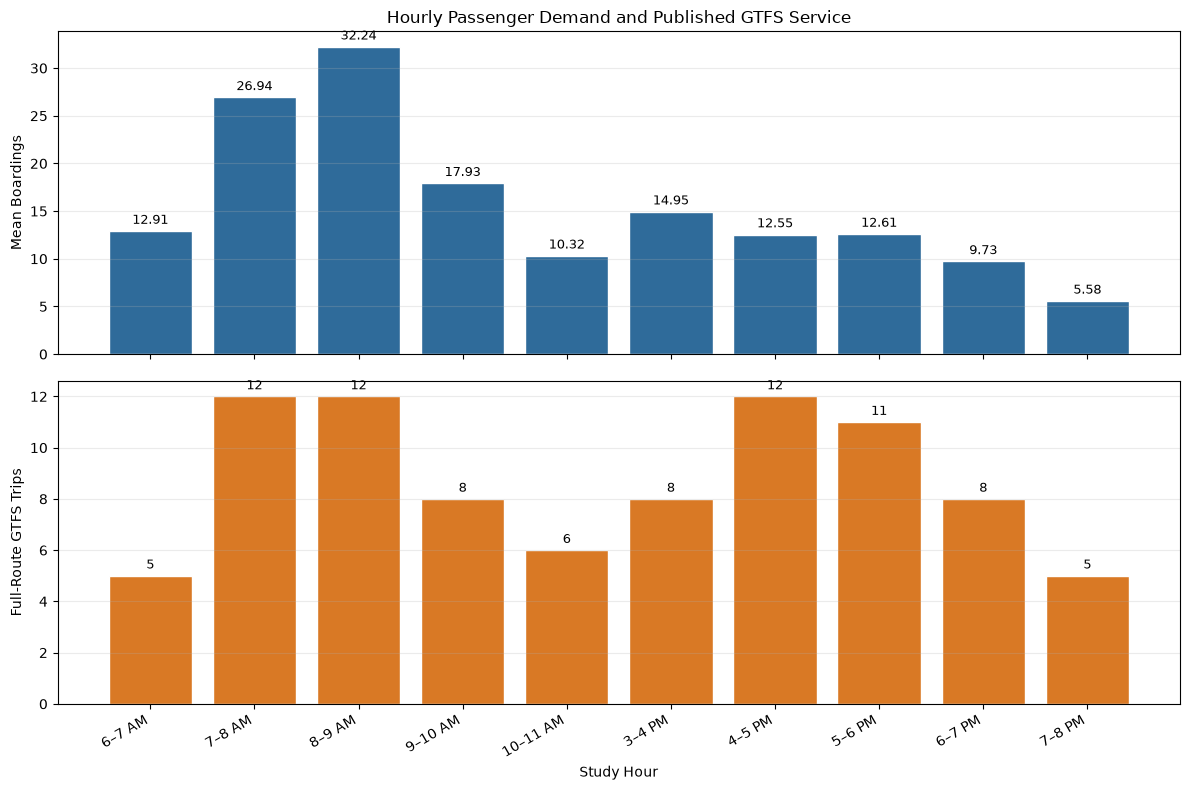

,Hour,Hour Label,Mean Boardings,Full-Route GTFS Trips
0,6,6–7 AM,12.914422,5
1,7,7–8 AM,26.941085,12
2,8,8–9 AM,32.244755,12
3,9,9–10 AM,17.929348,8
4,10,10–11 AM,10.319315,6
5,15,3–4 PM,14.945946,8
6,16,4–5 PM,12.546863,12
7,17,5–6 PM,12.607858,11
8,18,6–7 PM,9.729667,8
9,19,7–8 PM,5.583876,5


In [36]:
# Calculate mean selected-stop boardings for each study hour.
hourly_demand = (
    df_clean
    .assign(Study_Hour=df_clean["Hour"].dt.hour)
    .groupby("Study_Hour")["Boardings"]
    .mean()
    .reindex(study_hours)
)

# Count verified full-route GTFS trips using the arrival hour at Stop Sequence 6.
hourly_gtfs_trips = (
    trip_times
    .groupby("hour")["trip_id"]
    .nunique()
    .reindex(study_hours)
    .fillna(0)
    .astype(int)
)

hour_labels = [
    "6–7 AM",
    "7–8 AM",
    "8–9 AM",
    "9–10 AM",
    "10–11 AM",
    "3–4 PM",
    "4–5 PM",
    "5–6 PM",
    "6–7 PM",
    "7–8 PM"
]

x_positions = np.arange(len(study_hours))

# Use separate aligned charts because boardings and trips have different units.
fig, axes = plt.subplots(
    2,
    1,
    figsize=(12, 8),
    sharex=True
)

# Top chart: passenger demand.
demand_bars = axes[0].bar(
    x_positions,
    hourly_demand.values,
    color="#2F6B9A",
    edgecolor="white"
)

axes[0].set_title(
    "Hourly Passenger Demand and Published GTFS Service"
)
axes[0].set_ylabel("Mean Boardings")
axes[0].grid(axis="y", alpha=0.25)
axes[0].bar_label(
    demand_bars,
    fmt="%.2f",
    padding=3,
    fontsize=9
)

# Bottom chart: published GTFS trip supply.
trip_bars = axes[1].bar(
    x_positions,
    hourly_gtfs_trips.values,
    color="#D97925",
    edgecolor="white"
)

axes[1].set_xlabel("Study Hour")
axes[1].set_ylabel("Full-Route GTFS Trips")
axes[1].set_xticks(x_positions)
axes[1].set_xticklabels(
    hour_labels,
    rotation=30,
    ha="right"
)
axes[1].grid(axis="y", alpha=0.25)
axes[1].bar_label(
    trip_bars,
    fmt="%d",
    padding=3,
    fontsize=9
)

plt.tight_layout()

plt.savefig(
    "../outputs/figures/06_hourly_demand_and_gtfs_service.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Save the plotted values as reproducibility evidence.
hourly_demand_service = pd.DataFrame({
    "Hour": study_hours,
    "Hour Label": hour_labels,
    "Mean Boardings": hourly_demand.values,
    "Full-Route GTFS Trips": hourly_gtfs_trips.values
})

hourly_demand_service.to_csv(
    "../outputs/tables/hourly_demand_and_gtfs_service.csv",
    index=False
)

hourly_demand_service

In [37]:
# Build a compact summary of the verified data-quality checks.
data_quality_summary = pd.DataFrame({
    "Check": [
        "Selected records before cleaning",
        "Missing cell values",
        "Exact duplicate rows",
        "Logical duplicate rows",
        "Negative values",
        "Passenger activity with zero trips",
        "Source-absent date-stop-hour combinations",
        "Unavailable combinations after cleaning",
        "Final cleaned records"
    ],
    "Result": [
        len(df_selected),
        missing_cell_values,
        exact_duplicates,
        logical_duplicates,
        negative_values,
        len(zero_trip_issue),
        len(missing_source),
        len(unavailable_clean),
        len(df_clean)
    ]
})

# Record the complete filtering path from the website source to the cleaned analysis dataset.
filtering_summary = pd.DataFrame({
    "Stage": [
        "Full MTA dataset",
        "2025 only",
        "2025 + M66",
        "2025 + M66 + Eastbound",
        "Weekdays only",
        "Study hours only",
        "Selected stop sequences 6-10",
        "Final cleaned selected dataset"
    ],
    "Records": [
        155387648,
        92202449,
        165888,
        86959,
        64531,
        35372,
        12815,
        12814
    ]
})

print("Data quality summary:")
display(data_quality_summary)

print("Filtering summary:")
display(filtering_summary)

Data quality summary:


,Check,Result
0,Selected records before cleaning,12815
1,Missing cell values,0
2,Exact duplicate rows,0
3,Logical duplicate rows,0
4,Negative values,0
5,Passenger activity with zero trips,1
6,Source-absent date-stop-hour combinations,235
7,Unavailable combinations after cleaning,236
8,Final cleaned records,12814


Filtering summary:


,Stage,Records
0,Full MTA dataset,155387648
1,2025 only,92202449
2,2025 + M66,165888
3,2025 + M66 + Eastbound,86959
4,Weekdays only,64531
5,Study hours only,35372
6,Selected stop sequences 6-10,12815
7,Final cleaned selected dataset,12814


In [38]:
# Save the main analysis tables used by the Dataset Analysis section.
stop_period_summary.to_csv(
    "../outputs/tables/stop_period_summary.csv"
)

period_summary.to_csv(
    "../outputs/tables/period_summary.csv"
)

stop_stats.to_csv(
    "../outputs/tables/stop_boarding_statistics.csv"
)

hour_summary.to_csv(
    "../outputs/tables/hour_summary.csv"
)

# Save the corrected data-quality summary.
data_quality_summary.to_csv(
    "../outputs/tables/data_quality_summary.csv",
    index=False
)

# Save the website/Python filtering record counts.
filtering_summary.to_csv(
    "../outputs/tables/filtering_summary.csv",
    index=False
)

# Save source-absent combination summaries for reproducibility.
missing_by_stop.to_csv(
    "../outputs/tables/source_absent_by_stop.csv"
)

missing_by_hour.to_csv(
    "../outputs/tables/source_absent_by_hour.csv"
)

print("Analysis and data-quality tables saved.")

Analysis and data-quality tables saved.


In [39]:
# TECHNICAL DOCUMENTATION USED
# MTA Bus Stop Level Ridership:
# https://data.ny.gov/d/fvdm-uavx
#
# MTA Developer Resources / Static GTFS:
# https://www.mta.info/developers
#
# GTFS Schedule Reference:
# https://gtfs.org/documentation/schedule/reference/
#
# pandas documentation:
# https://pandas.pydata.org/docs/
#
# NumPy documentation:
# https://numpy.org/doc/
#
# Matplotlib documentation:
# https://matplotlib.org/stable/
#
# Python pathlib documentation:
# https://docs.python.org/3/library/pathlib.html